In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("dataset/renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

# Optional: inspect the first rows
print(dataset.head())




# %%


                       Time ID  demand_MWh  supply_MWh  solar_MWh   wind_MWh  \
0 2012-01-01 00:00:00+00:00  1     75.6549    9.150821        0.0  18.301642   
1 2012-01-01 00:00:00+00:00  2    557.8868    6.196411        0.0  12.392822   
2 2012-01-01 00:00:00+00:00  3     15.5237    6.855084        0.0  13.710167   
3 2012-01-01 00:00:00+00:00  4      8.6425    7.824092        0.0  15.648183   
4 2012-01-01 00:00:00+00:00  5     85.3649    2.053690        0.0   4.107380   

   solar_rel_prod  wind_rel_prod   latitude  longitude country  \
0             0.0         0.0284  42.094674  -8.113982     POR   
1             0.0         0.0103  41.587435  -8.326462     POR   
2             0.0         0.0283  41.585994  -6.722728     POR   
3             0.0         0.0408  41.597684  -6.342848     POR   
4             0.0         0.0092  41.373957  -7.350949     POR   

   solar_layout_MW  wind_layout_MW  
0         982.8607        644.4240  
1        1361.0601       1203.1866  
2         7

In [5]:
import numpy as np 

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [4]:
dataset = dataset[["Time", "country", "demand_MWh"]]
dataset = dataset.set_index("Time")

In [9]:
countries = dataset["country"].unique()
country = countries[0]
country_df = dataset[dataset["country"] == country]
country_df = country_df.drop(columns=["country"])
country_df = country_df.groupby([country_df.index]).sum()
country_mean = np.mean(country_df["demand_MWh"])
country_std = np.std(country_df["demand_MWh"])
country_df["demand_MWh"] = (country_df["demand_MWh"] - country_mean)/country_std

In [10]:
country_df["hour"] = country_df.index.hour
country_df["day_of_week"] = country_df.index.day_of_week
country_df["month"] = country_df.index.month

In [51]:
reg_df = pd.get_dummies(country_df, columns = ["day_of_week"], prefix = "day_of_week", drop_first = False)
reg_df = pd.get_dummies(reg_df, columns = ["month"], prefix = "month", drop_first = False)
#reg_df = pd.get_dummies(reg_df, columns = ["hour"], prefix = "hour", drop_first = False)


In [54]:
X = reg_df.to_numpy()[:, 1:].astype(float)
y = reg_df .to_numpy()[:, 0].astype(float)

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [14]:
def diff(x, lags):
    return x[lags:] - x[:-lags]

In [ ]:
plot_acf(X[:,0], lags = 10)

In [15]:
import statsmodels.api as sm

In [55]:
model = sm.OLS(y, X)
res = model.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.614
Model:                            OLS   Adj. R-squared:                  0.614
Method:                 Least Squares   F-statistic:                     2327.
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:50:21   Log-Likelihood:                -24788.
No. Observations:               26304   AIC:                         4.961e+04
Df Residuals:                   26285   BIC:                         4.977e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0864      0.001    156.122      0.0

In [56]:
X.shape

(26304, 20)

In [57]:
day_params = res.params[1:8]
month_params = res.params[8:]


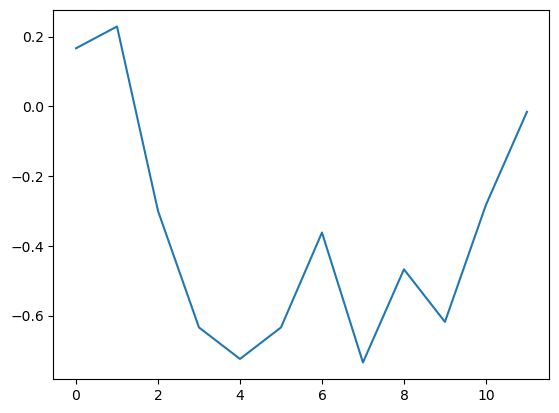

In [60]:
plt.plot(month_params)

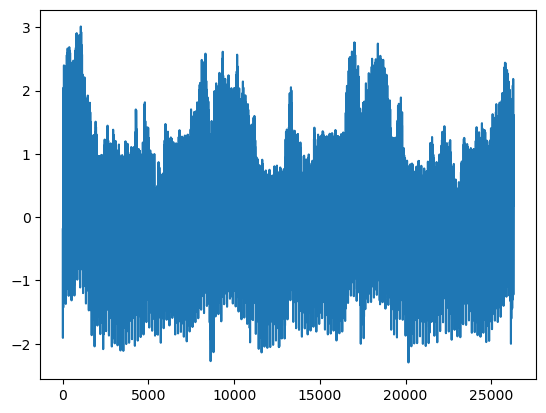

In [40]:
plt.plot(y)

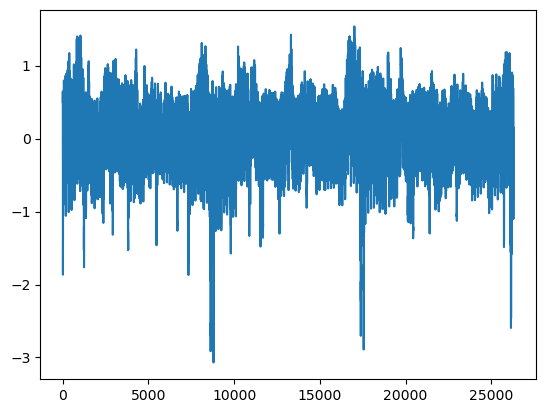

In [47]:
plt.plot(res.resid)

In [ ]:
plt.plot()

In [ ]:
dataset = dataset[["Time", "demand_MWh", "ID", "country"]]
dataset = 

In [3]:
countries = [country for country in dataset["country"].unique()]

<Axes: xlabel='Time'>

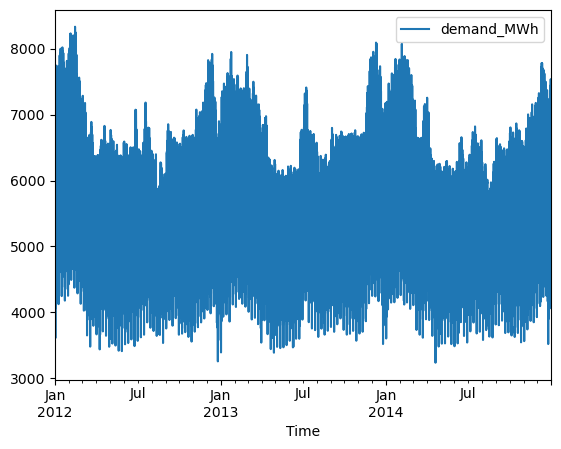

In [4]:
country_dataset = dataset[dataset["country"] == countries[0]][["Time", "demand_MWh"]]
country_dataset.groupby(["Time"]).sum().plot()

In [5]:
def get_demand_country(country):
    country_dataset = dataset[dataset["country"] == country][["Time", "demand_MWh"]]
    country_dataset = country_dataset.groupby(["Time"]).sum()
    return country_dataset

In [6]:
from statsmodels.tsa.seasonal import MSTL, DecomposeResult

In [ ]:
country = get_demand_country(countries[0])


In [ ]:
country_day = country.resample("D").sum()

<Axes: xlabel='Time'>

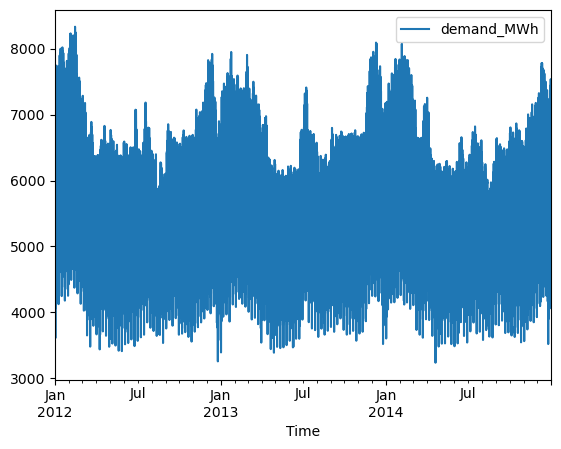

In [18]:
country.resample("h").mean().plot()

<Axes: xlabel='Time'>

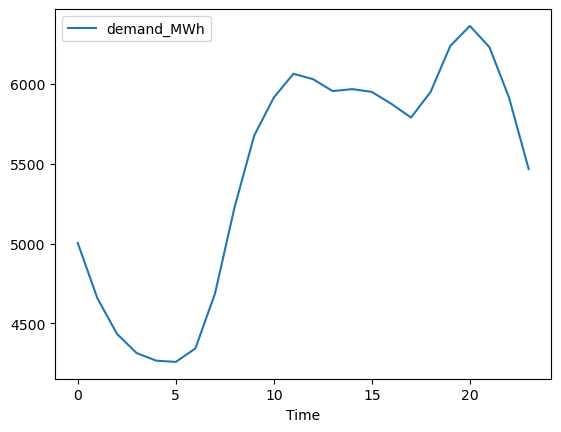

In [23]:
country.groupby([country.index.hour]).mean().plot()

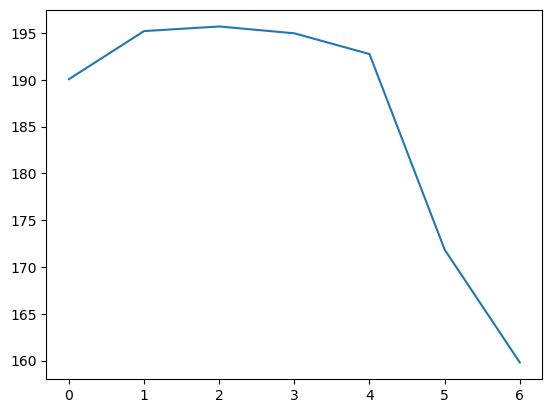

In [31]:
#plt.plot(country.groupby([country.index.day_of_week]).mean())
plt.plot(demand_df.groupby([demand_df.index.day_of_week]).mean())

<Axes: xlabel='Time'>

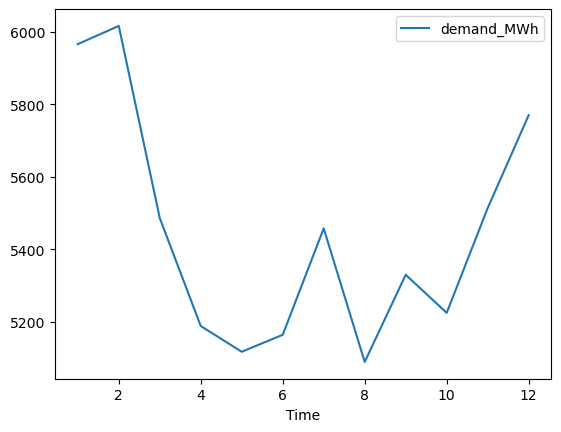

In [24]:
country.groupby([country.index.month]).mean().plot()

<Axes: xlabel='Time'>

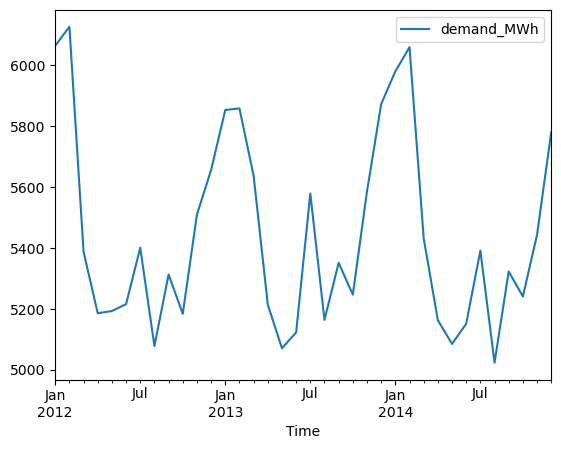

In [15]:
country.resample("ME").mean().plot()

(array([   2.,    9.,   36.,   52.,  139.,  257.,  429.,  499.,  637.,
         914., 1112., 1022., 1067., 1011.,  948.,  917.,  854.,  901.,
         791.,  651.,  612.,  568.,  604.,  647.,  802.,  986., 1177.,
        1243., 1067.,  923.,  810.,  729.,  622.,  595.,  499.,  400.,
         393.,  324.,  274.,  207.,  157.,  111.,   99.,   74.,   58.,
          38.,   20.,   10.,    4.,    3.]),
 array([3236.6411 , 3338.54977, 3440.45844, 3542.36711, 3644.27578,
        3746.18445, 3848.09312, 3950.00179, 4051.91046, 4153.81913,
        4255.7278 , 4357.63647, 4459.54514, 4561.45381, 4663.36248,
        4765.27115, 4867.17982, 4969.08849, 5070.99716, 5172.90583,
        5274.8145 , 5376.72317, 5478.63184, 5580.54051, 5682.44918,
        5784.35785, 5886.26652, 5988.17519, 6090.08386, 6191.99253,
        6293.9012 , 6395.80987, 6497.71854, 6599.62721, 6701.53588,
        6803.44455, 6905.35322, 7007.26189, 7109.17056, 7211.07923,
        7312.9879 , 7414.89657, 7516.80524, 7618.71391, 

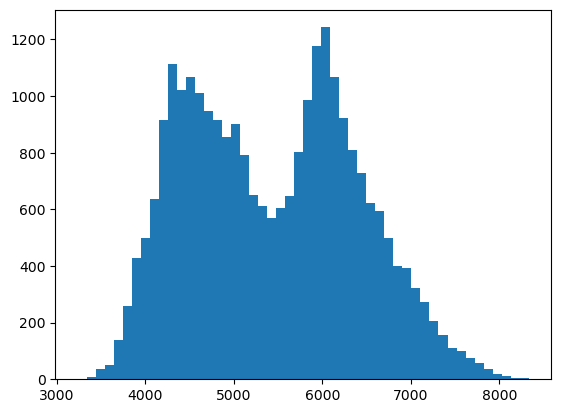

In [11]:
plt.hist(country["demand_MWh"], bins = 50)

(array([  1.,   1.,   1.,  14.,  31.,  23.,  33.,  36.,  36.,  29.,  27.,
         32.,  37.,  41.,  96., 110.,  94.,  95.,  65.,  50.,  33.,  29.,
         37.,  30.,  23.,  39.,  27.,  15.,   9.,   2.]),
 array([ 95320.878  ,  97543.69758,  99766.51716, 101989.33674,
        104212.15632, 106434.9759 , 108657.79548, 110880.61506,
        113103.43464, 115326.25422, 117549.0738 , 119771.89338,
        121994.71296, 124217.53254, 126440.35212, 128663.1717 ,
        130885.99128, 133108.81086, 135331.63044, 137554.45002,
        139777.2696 , 142000.08918, 144222.90876, 146445.72834,
        148668.54792, 150891.3675 , 153114.18708, 155337.00666,
        157559.82624, 159782.64582, 162005.4654 ]),
 <BarContainer object of 30 artists>)

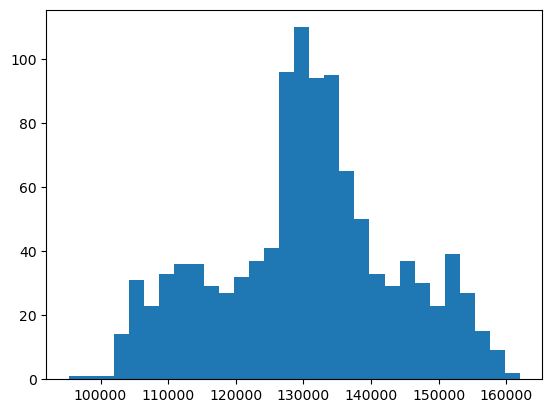

In [13]:
plt.hist(country_day["demand_MWh"], bins = 30)

In [28]:
demand_arr = country["demand_MWh"].to_numpy()
def diff(arr, lag):
    return arr[lag:] - arr[:-lag]

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(demand_arr, order = (2,))

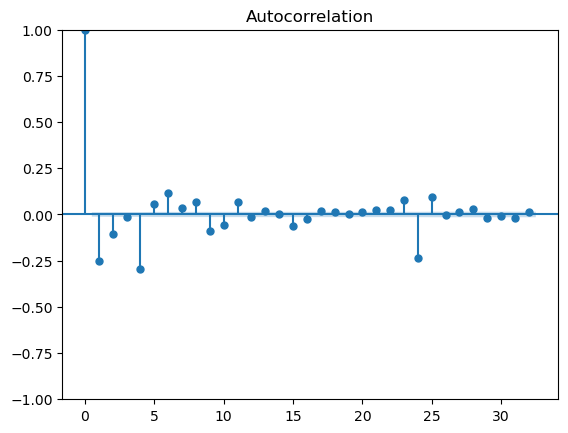

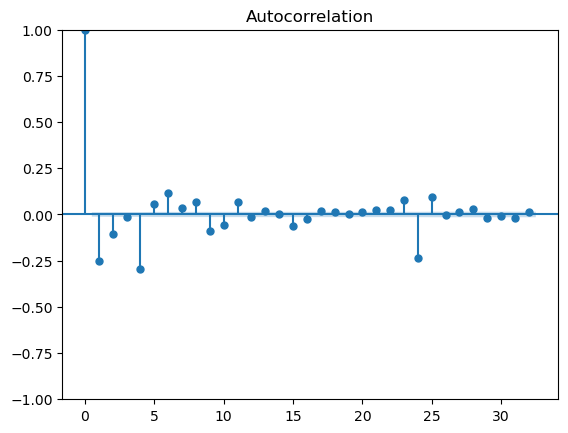

In [37]:
plot_acf(diff(diff(diff(demand_arr, 24), 1), 1), lags = 32)

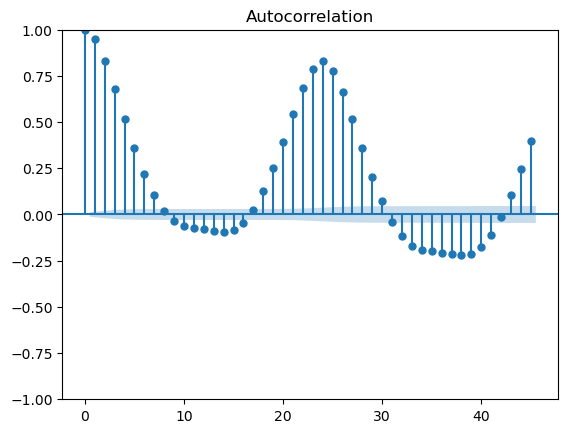

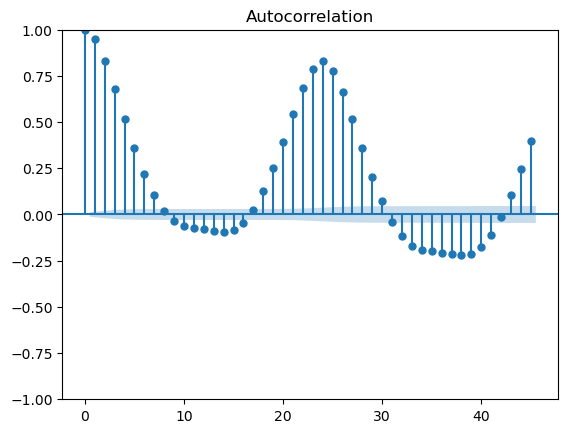

In [33]:
plot_acf(country["demand_MWh"])

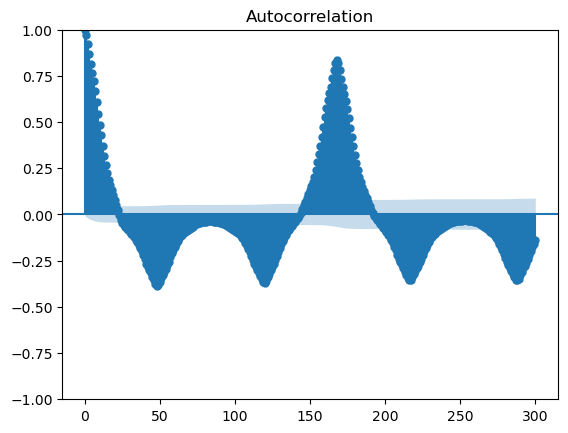

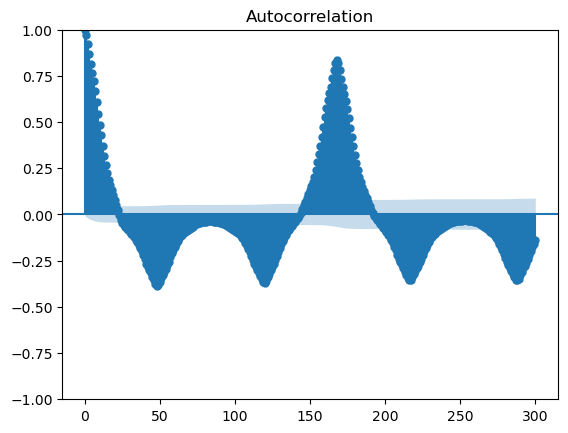

In [34]:
plot_acf(country["demand_MWh"][24:].to_numpy() - country["demand_MWh"][:-24].to_numpy(), lags = 300)

In [11]:
stl = MSTL(country, periods = [24, 7 * 24, 365 * 24]) 

In [12]:
res = stl.fit()

<Axes: xlabel='Time'>

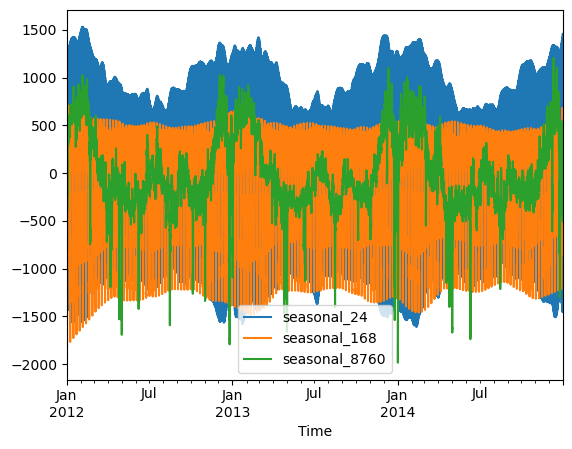

In [17]:
res.seasonal.plot()

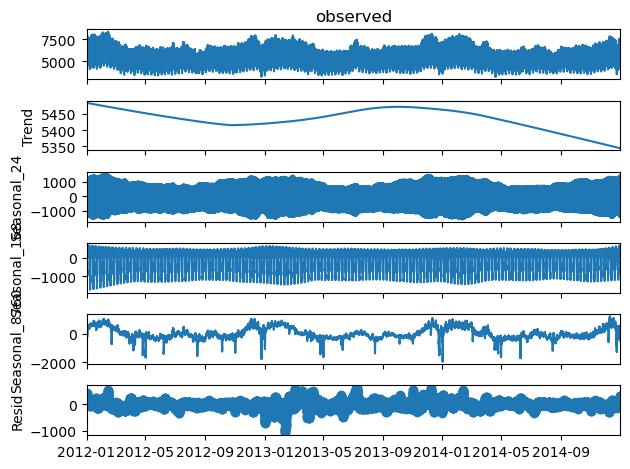

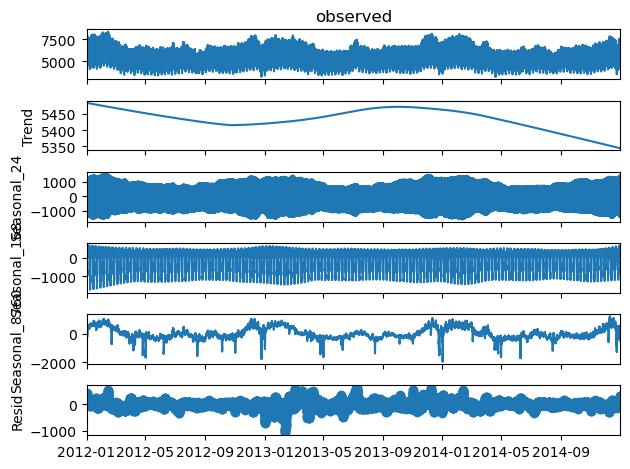

In [13]:
res.plot()

(array([ 2.,  0.,  2.,  3.,  2.,  2.,  2.,  0.,  1.,  4.,  5.,  2.,  2.,
         3.,  0.,  1., 15.,  5., 10., 31., 67., 90., 64., 65., 53., 65.,
        67., 71., 68., 49., 42., 38., 39., 43., 36., 33., 22., 18., 21.,
        14., 13.,  4.,  3.,  3.,  3.,  2.,  3.,  1.,  6.,  1.]),
 array([481830.93975191, 488799.91450402, 495768.88925614, 502737.86400825,
        509706.83876036, 516675.81351248, 523644.78826459, 530613.7630167 ,
        537582.73776882, 544551.71252093, 551520.68727304, 558489.66202516,
        565458.63677727, 572427.61152938, 579396.5862815 , 586365.56103361,
        593334.53578572, 600303.51053784, 607272.48528995, 614241.46004206,
        621210.43479418, 628179.40954629, 635148.3842984 , 642117.35905051,
        649086.33380263, 656055.30855474, 663024.28330685, 669993.25805897,
        676962.23281108, 683931.20756319, 690900.18231531, 697869.15706742,
        704838.13181953, 711807.10657165, 718776.08132376, 725745.05607587,
        732714.03082799, 739683.

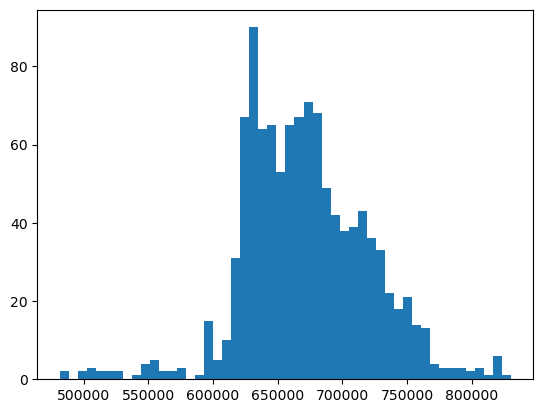

In [84]:
plt.hist(res.resid + res.trend, bins = 50)

In [8]:
dataset.set_index("Time", inplace=True)
dataset.resample("D").mean().plot()

TypeError: agg function failed [how->mean,dtype->object]

In [ ]:
# ----------------------------------------------
# 2. Choose penetration/scaling for solar + wind
# ----------------------------------------------
# These scale the already-computed solar_MWh and wind_MWh columns
a_s = 0.01  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.05  # wind matches (a_w x 100)% of the average yearly demand across EU


# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "ID",
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

# Optional: inspect the result
print(dataset_residual.head())

# %% ---------------------------------------------------------
# 3. Filter to one node and to the dates 7-10 August 2013
# ---------------------------------------------------------
# Important: ID is stored as a string
subset_station = dataset_residual.loc[dataset_residual["ID"] == "1"].drop(columns="ID")

# %%
mask = (
    (subset_station["Time"].dt.year == 2013)
    & (subset_station["Time"].dt.month == 8)
    & (subset_station["Time"].dt.day.isin([7, 8, 9, 10]))
)

subset_data = subset_station.loc[mask].melt(
    id_vars="Time",
    var_name="source",
    value_name="MWh",
)

# Optional: inspect filtered long-format data
print(subset_data.head())


# -------------------------------
# 4. Plot the selected time series
# -------------------------------
plt.figure(figsize=(12, 5))

for source, group in subset_data.groupby("source"):
    plt.plot(group["Time"], group["MWh"], label=source)

plt.xlabel("Time")
plt.ylabel("MWh")
plt.title("Supply, demand, and residual load at node 1 (7–10 Aug 2013)")
plt.legend()
plt.tight_layout()
plt.show()